In [6]:
from huggingface_hub import snapshot_download

from utils.download_kaggle_dataset import download_kaggle_competition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
data = download_kaggle_competition("prediction-interval-competition-ii-house-price")
print(data)
data_set = pd.read_csv(f"{data}/dataset.csv")
test_set = pd.read_csv(f"{data}/test.csv")

Unzipping files...
Competition data downloaded to: datasets
datasets


In [8]:
data_set.head()

,id,sale_date,sale_price,sale_nbr,sale_warning,join_status,join_year,latitude,longitude,area,...,view_olympics,view_cascades,view_territorial,view_skyline,view_sound,view_lakewash,view_lakesamm,view_otherwater,view_other,submarket
0,0,2014-11-15,236000,2.0,,nochg,2025,47.2917,-122.3658,53,...,0,0,0,0,0,0,0,0,0,I
1,1,1999-01-15,313300,NaN,26,nochg,2025,47.6531,-122.1996,74,...,0,0,0,0,0,1,0,0,0,Q
2,2,2006-08-15,341000,1.0,,nochg,2025,47.4733,-122.1901,30,...,0,0,0,0,0,0,0,0,0,K
3,3,1999-12-15,267000,1.0,,nochg,2025,47.4739,-122.3295,96,...,0,0,0,0,0,0,0,0,0,G
4,4,2018-07-15,1650000,2.0,,miss99,2025,47.7516,-122.1222,36,...,0,0,0,0,0,0,0,0,0,P


In [9]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 47 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                200000 non-null  int64  
 1   sale_date         200000 non-null  object 
 2   sale_price        200000 non-null  int64  
 3   sale_nbr          157818 non-null  float64
 4   sale_warning      200000 non-null  object 
 5   join_status       200000 non-null  object 
 6   join_year         200000 non-null  int64  
 7   latitude          200000 non-null  float64
 8   longitude         200000 non-null  float64
 9   area              200000 non-null  int64  
 10  city              200000 non-null  object 
 11  zoning            200000 non-null  object 
 12  subdivision       182450 non-null  object 
 13  present_use       200000 non-null  int64  
 14  land_val          200000 non-null  int64  
 15  imp_val           200000 non-null  int64  
 16  year_built        20

In [10]:
data_set.describe()

,id,sale_price,sale_nbr,join_year,latitude,longitude,area,present_use,land_val,imp_val,...,view_rainier,view_olympics,view_cascades,view_territorial,view_skyline,view_sound,view_lakewash,view_lakesamm,view_otherwater,view_other
count,200000.000000,2.000000e+05,157818.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,2.000000e+05,2.000000e+05,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,99999.500000,5.841495e+05,2.162599,2023.403600,47.549248,-122.210416,48.644215,4.108860,4.601691e+05,4.917715e+05,...,0.017940,0.053985,0.058800,0.215550,0.018425,0.055565,0.050075,0.014090,0.020875,0.013455
std,57735.171256,4.170595e+05,1.113090,6.241643,0.142710,0.140339,27.132002,7.199323,3.510444e+05,3.680505e+05,...,0.218994,0.379119,0.381868,0.724224,0.222746,0.380011,0.353664,0.200154,0.248977,0.181147
min,0.000000,5.029300e+04,1.000000,1999.000000,47.155200,-122.527700,1.000000,2.000000,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49999.750000,3.050000e+05,1.000000,2025.000000,47.446500,-122.323800,26.000000,2.000000,2.310000e+05,2.800000e+05,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,99999.500000,4.599500e+05,2.000000,2025.000000,47.562800,-122.222700,48.000000,2.000000,3.770000e+05,4.090000e+05,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,149999.250000,7.249500e+05,3.000000,2025.000000,47.673500,-122.121700,71.000000,2.000000,5.940000e+05,5.990000e+05,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,199999.000000,2.999950e+06,11.000000,2025.000000,47.777800,-121.161300,100.000000,29.000000,1.386400e+07,1.006700e+07,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [11]:
data_set.isnull().sum()

id                      0
sale_date               0
sale_price              0
sale_nbr            42182
sale_warning            0
join_status             0
join_year               0
latitude                0
longitude               0
area                    0
city                    0
zoning                  0
subdivision         17550
present_use             0
land_val                0
imp_val                 0
year_built              0
year_reno               0
sqft_lot                0
sqft                    0
sqft_1                  0
sqft_fbsmt              0
grade                   0
fbsmt_grade             0
condition               0
stories                 0
beds                    0
bath_full               0
bath_3qtr               0
bath_half               0
garb_sqft               0
gara_sqft               0
wfnt                    0
golf                    0
greenbelt               0
noise_traffic           0
view_rainier            0
view_olympics           0
view_cascade

In [12]:
data_set.isnull().sum()

id                      0
sale_date               0
sale_price              0
sale_nbr            42182
sale_warning            0
join_status             0
join_year               0
latitude                0
longitude               0
area                    0
city                    0
zoning                  0
subdivision         17550
present_use             0
land_val                0
imp_val                 0
year_built              0
year_reno               0
sqft_lot                0
sqft                    0
sqft_1                  0
sqft_fbsmt              0
grade                   0
fbsmt_grade             0
condition               0
stories                 0
beds                    0
bath_full               0
bath_3qtr               0
bath_half               0
garb_sqft               0
gara_sqft               0
wfnt                    0
golf                    0
greenbelt               0
noise_traffic           0
view_rainier            0
view_olympics           0
view_cascade

<Axes: >

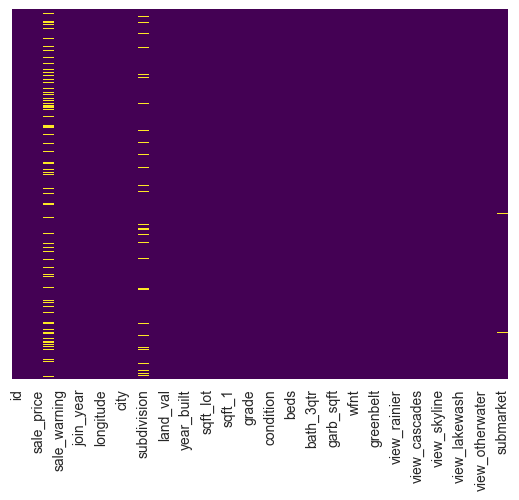

In [14]:
sns.heatmap(data_set.isnull(), cbar=False, yticklabels=False, cmap='viridis')

NameError: name 'snapshot_download' is not defined